In [2]:
import cv2
import os

def process_video(input_video, extract_interval=5, output_dir='.',output_folder='default'):
    # 获取视频名称
    video_name = input_video.split('\\')[-1][:20]
    # 创建输出目录
    if output_folder == 'default':
        picture_save_path = os.path.join(output_dir,video_name)
    else:
        picture_save_path = os.path.join(output_dir,output_folder)

    if not os.path.exists(picture_save_path):
        os.makedirs(picture_save_path, exist_ok=True)
    else:
        print(f'Path already exists! Path: {picture_save_path}')
    
    # # 加载人脸检测分类器（需确保haarcascade_frontalface_default.xml存在）
    # face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # 打开视频文件
    cap = cv2.VideoCapture(input_video)
    
    # 获取视频帧率
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = extract_interval * int(fps)  # 每x秒取1帧
    
    frame_count = 0
    saved_count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # 每秒处理一帧
        if frame_count % frame_interval == 0:
            # 保存图片
            output_path = os.path.join(picture_save_path, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(output_path, frame, [cv2.IMWRITE_JPEG_QUALITY, 100])
            
            saved_count += 1
            
        frame_count += 1
    
    cap.release()
    print(f"处理完成，共保存 {saved_count} 张图片")

# 使用示例
input_video = r'F:\FFOUT\【黎明杀机】韩服单排 可恶小黑妹坏我大计！克劳黛特·莫莱 竟比追击者还壮实 - 1.【黎明杀机】韩服单排 可恶小黑妹坏我大计！克劳黛特·莫莱 竟比追击者还壮实(Av114116307982253,P1) 00_00_00-00_11_09.mp4'
output_dir = r'D:\files\code\dbd_pred\picture'
output_folder = r'test1'
extract_interval = 60
process_video(input_video,extract_interval,output_dir,output_folder)

Path already exists! Path: D:\files\code\dbd_pred\picture\test1
处理完成，共保存 12 张图片


In [12]:
def extract_

'【黎明杀机】韩服单排 可恶小黑妹坏我大计'

In [8]:
# import cv2
 
 
# # 读取图片，第二个参数为False时，显示为灰度图像，True为原图
# img = cv2.imread(filename=r"D:\files\code\dbd_pred\picture\test1\frame_0006.jpg",flags=0)
 
# # # 显示图片，第一个参数为图片的标题
# # cv2.imshow(winname="image title", mat=img)
 
# region = img
# print(img)
# # cv2.imshow("img", region)
# # # 等待图片的关闭，不写这句图片会一闪而过
# # cv2.waitKey()

import cv2
import numpy as np

def count_vertical_lines(img):
    # 2. 垂直边缘检测（使用 Sobel 算子）
    sobel_vertical = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ], dtype=np.float32)
    edges = cv2.filter2D(img, cv2.CV_32F, sobel_vertical)
    edges = cv2.convertScaleAbs(edges)  # 转换为 uint8

    # 3. 二值化（阈值可调）
    _, binary = cv2.threshold(edges, 50, 255, cv2.THRESH_BINARY)

    # 4. 形态学闭操作（连接断裂的竖线）
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5))  # 调整高度以连接断裂
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # # 5. 霍夫变换检测直线（仅检测接近垂直的线）
    # lines = cv2.HoughLinesP(
    #     binary,          # 输入的二值边缘图像（需为单通道8位图像）
    #     rho=1,          # 极径分辨率（单位：像素）
    #     theta=np.pi/180, # 角度分辨率（单位：弧度）
    #     threshold=1,    # 累加器阈值（值越小，检测到的线段越多）
    #     minLineLength=0, # 线段最小长度（短于此长度的线段会被忽略）
    #     maxLineGap=0    # 线段最大间隔（间隔小于此值的线段会被合并）
    # )

    # # 6. 筛选垂直方向的线（角度接近90度）
    # vertical_lines = []
    # if lines is not None:
    #     for line in lines:
    #         x1, y1, x2, y2 = line[0]
    #         angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    #         if abs(angle - 90) < 5:  # 允许±5度的偏差
    #             vertical_lines.append(line)
    #             # 可选：在图像上绘制检测到的线
    #             cv2.line(img, (x1, y1), (x2, y2), (125, 255, 83), 2)

    # print(f"检测到 {len(vertical_lines)} 条竖线")

    # 2. 连通区域分析替代霍夫变换
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    vertical_lines = 0
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)  # 用于绘制结果的彩色图

    for cnt in contours:
        # 3. 计算轮廓的最小外接矩形
        rect = cv2.minAreaRect(cnt)
        (x, y), (w, h), angle = rect
        
        # 4. 筛选条件：长宽比和角度
        # 微小竖线条件：高度 >=10px，宽度 <=2px，角度接近90度
        if h >= 1 and w >= 20 and (abs(angle - 90) < 20 or abs(angle + 90) < 20):
            vertical_lines += 1
            # 绘制外接矩形
            box = cv2.boxPoints(rect)
            box = np.int64(box)
            cv2.drawContours(result_img, [box], 0, (0, 255, 0), 1)

    print(f"检测到 {vertical_lines} 条微小竖线")
    
    # 可选：显示结果
    cv2.imshow("Edges", edges)
    cv2.imshow("Binary", binary)
    cv2.imshow("Closed", closed)
    cv2.imshow("Result", result_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# 使用示例
image_path = r"D:\files\code\dbd_pred\picture\test1\frame_0006.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("图像加载失败，请检查路径")

size_x, size_y= img.shape
for i in range(1):
    # plt_show_cv2_image(image_path,range_x=[0.475+i*0.08,0.505+i*0.08],range_y=[0.115,0.135])
    # 1. 读取灰度图

    range_x=[0.475+i*0.08,0.505+i*0.08]
    range_y=[0.115,0.135]
    low_limit_x, up_limit_x = [int(size_x*lmt) for lmt in range_x]
    low_limit_y, up_limit_y = [int(size_y*lmt) for lmt in range_y]
    img1 = img[low_limit_x:up_limit_x, low_limit_y:up_limit_y]

    count = count_vertical_lines(img)
 

检测到 0 条微小竖线


In [71]:
# coding=utf-8
import cv2
import numpy as np
 
img = cv2.imread(r"D:\files\code\dbd_pred\picture\test1\frame_0006.jpg")
 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
 
gaus = cv2.GaussianBlur(gray,(3,3),0)
 
edges = cv2.Canny(gaus, 50, 150, apertureSize=3)
 
minLineLength = 100
maxLineGap = 10
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength, maxLineGap)
 
for x1, y1, x2, y2 in lines[0]:
    cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
 
cv2.imshow("houghline",img)
cv2.waitKey()
cv2.destroyAllWindows()

In [8]:
import matplotlib.pyplot as plt
import cv2

# 使用plt显示cv2格式的图片
def plt_show_cv2_image(image_path,range_x=[0,1],range_y=[0,1]):
    image = cv2.imread(filename=image_path,flags=0)
    image0 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # print(image0.shape)
    size_x, size_y, ch = image0.shape
    low_limit_x, up_limit_x = [int(size_x*lmt) for lmt in range_x]
    low_limit_y, up_limit_y = [int(size_y*lmt) for lmt in range_y]
    
    plt.figure()  # 打开一个画布
    plt.axis('off')  # 不打开坐标轴
    plt.imshow(image0[low_limit_x:up_limit_x, low_limit_y:up_limit_y])
    plt.show()  # 加上这个才能显示
    # plt.pause(0.01)  # 暂时显示0.01秒
    # plt.draw()  # 重新绘制当前图形

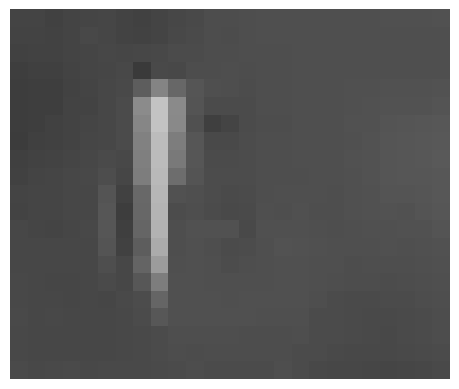

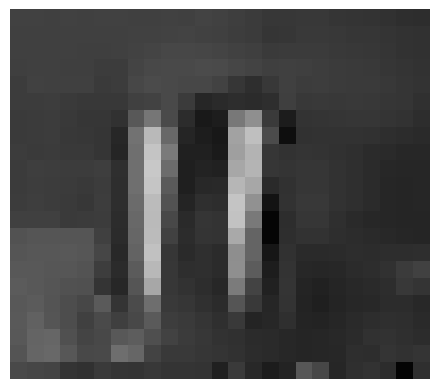

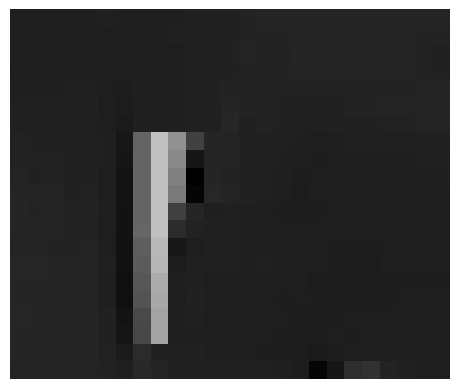

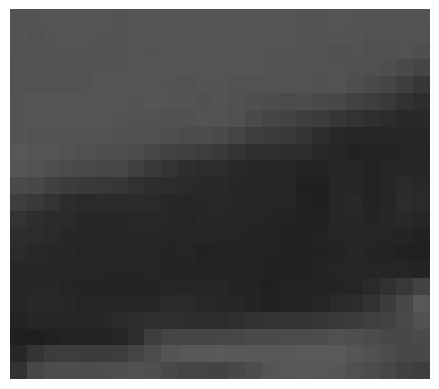

In [20]:
image_path = r"D:\files\code\dbd_pred\picture\test1\frame_0006.jpg"
for i in range(4):
    plt_show_cv2_image(image_path,range_x=[0.475+i*0.08,0.505+i*0.08],range_y=[0.115,0.135])